# 3 · External Validation（外部驗證）
**Outcome：** 把第 2 個 Notebook 建好的模型，原封不動套用到「獨立的外部世代」。

**Methods：** 不重新訓練，直接預測 → ROC / Brier / KM。

> 🧪 使用虛構的 `./Data/synthetic_external.csv`。

## 1. 載入外部世代與已存模型

In [1]:
import numpy as np, pandas as pd, joblib, os
import matplotlib.pyplot as plt
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 140, 'font.size': 12,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'figure.facecolor': 'white',
})
ACCENT = '#2f6df6'; ACCENT2 = '#f6862f'; GREY = '#9aa3b2'

ext = pd.read_csv('../Data/synthetic_external.csv')
bundle = joblib.load('../Data/demo_model.joblib')
model, features, cutoff = bundle['model'], bundle['features'], bundle['cutoff']
print('外部世代 shape:', ext.shape, '| 使用閾值:', round(cutoff,3))
ext.head()

外部世代 shape: (300, 8) | 使用閾值: 0.279


,PatientID,AJCC_Substage,LNR,Differentiation,PNI,edr_18m,DFS_Months,DFS_Events
0,DEMO-07-0000,2,0.163,3,0,0,17.2,0
1,DEMO-07-0001,1,0.349,3,0,0,60.0,0
2,DEMO-07-0002,2,0.164,3,0,1,16.6,1
3,DEMO-07-0003,2,0.523,1,1,0,60.0,1
4,DEMO-07-0004,2,0.022,2,1,0,2.0,0


## 2. 套用模型（**不重新訓練**）

In [2]:
Xe = ext[features].astype(float)
ye = ext['edr_18m'].astype(int)
prob = model.predict_proba(Xe)[:, 1]
ext['risk'] = np.where(prob >= cutoff, 'High risk', 'Low risk')
ext['risk'].value_counts()

risk
Low risk     154
High risk    146
Name: count, dtype: int64

## 3. 外部 ROC + Brier → 存檔

External AUC = 0.653 | Brier = 0.223


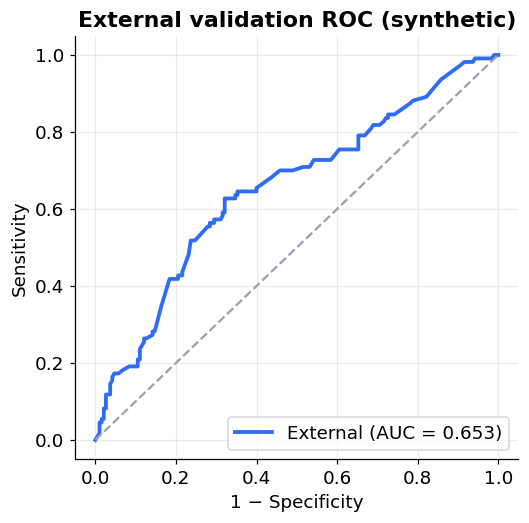

In [3]:
from sklearn.metrics import roc_curve, roc_auc_score, brier_score_loss
fpr, tpr, _ = roc_curve(ye, prob); auc = roc_auc_score(ye, prob)
fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot(fpr, tpr, color='#2f6df6', lw=2.5, label=f'External (AUC = {auc:.3f})')
ax.plot([0,1],[0,1],'--', color=GREY)
ax.set_xlabel('1 − Specificity'); ax.set_ylabel('Sensitivity')
ax.set_title('External validation ROC (synthetic)', fontweight='bold'); ax.legend(loc='lower right')
os.makedirs('../Figures', exist_ok=True)
fig.savefig('../Figures/fig5_roc_external.png', bbox_inches='tight')
print(f'External AUC = {auc:.3f} | Brier = {brier_score_loss(ye, prob):.3f}')

## 4. 外部 Kaplan–Meier → 存檔

已存檔 → ../Figures/fig6_km_external.png


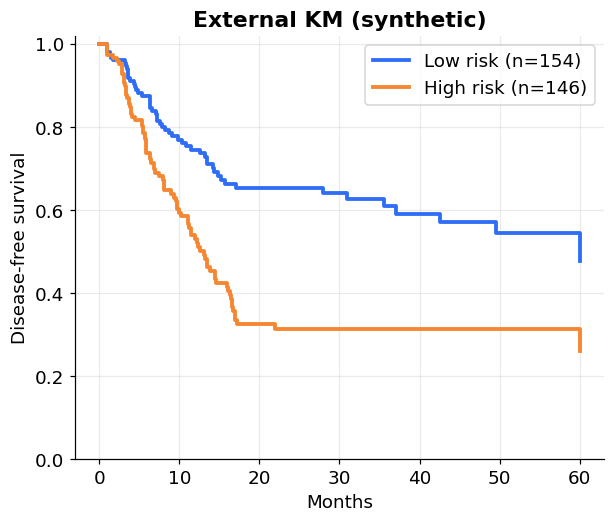

In [4]:
def km_curve(time, event):
    t = np.asarray(time); e = np.asarray(event); uniq = np.unique(t)
    surv = 1.0; xs=[0]; ys=[1.0]
    for ut in uniq:
        d = np.sum((t == ut) & (e == 1)); atr = np.sum(t >= ut)
        if atr > 0: surv *= (1 - d/atr)
        xs.append(ut); ys.append(surv)
    return np.array(xs), np.array(ys)
fig, ax = plt.subplots(figsize=(6.2, 5))
for grp, col in [('Low risk', '#2f6df6'), ('High risk', '#f6862f')]:
    sub = ext[ext.risk == grp]; xs, ys = km_curve(sub['DFS_Months'], sub['DFS_Events'])
    ax.step(xs, ys, where='post', color=col, lw=2.5, label=f'{grp} (n={len(sub)})')
ax.set_xlabel('Months'); ax.set_ylabel('Disease-free survival'); ax.set_ylim(0,1.02)
ax.set_title('External KM (synthetic)', fontweight='bold'); ax.legend()
fig.savefig('../Figures/fig6_km_external.png', bbox_inches='tight')
print('已存檔 → ../Figures/fig6_km_external.png')

## ✅ 全流程完成
`Data → Notebooks → Figures / Tables`，每一步都可重現。

這就是用 AI Agent 協助、但**結果完全由你掌控、可重現**的研究工作流程。